### Dataset Loading

In [23]:
import pandas as pd

gym_dataset = pd.read_csv("gym_members_exercise_tracking.csv")

gym_dataset_copy = gym_dataset.copy()
gym_dataset_copy.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### Removing False Predictors

### Data Vizualization

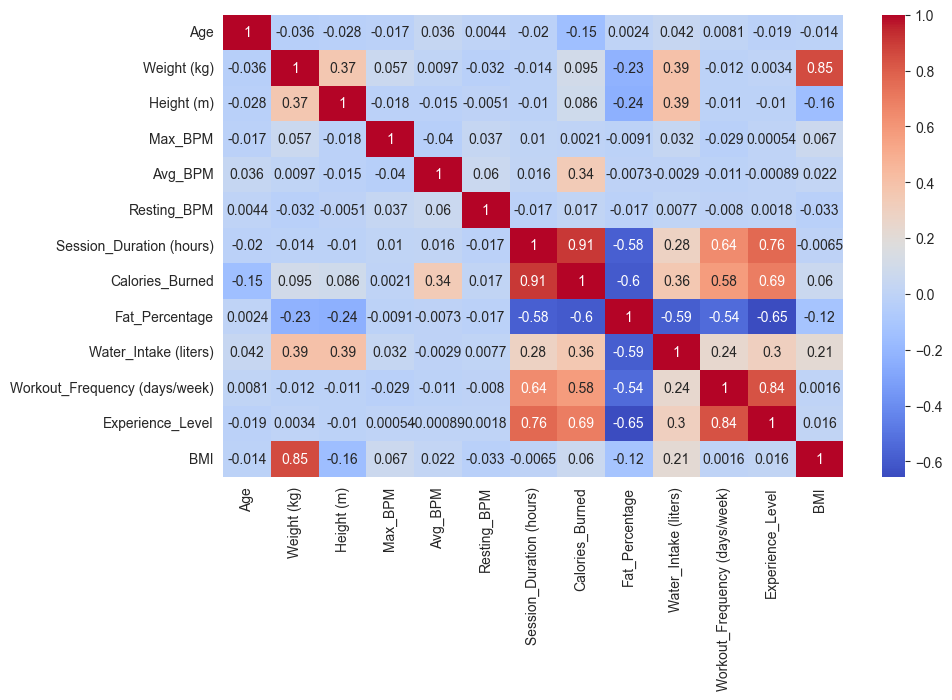

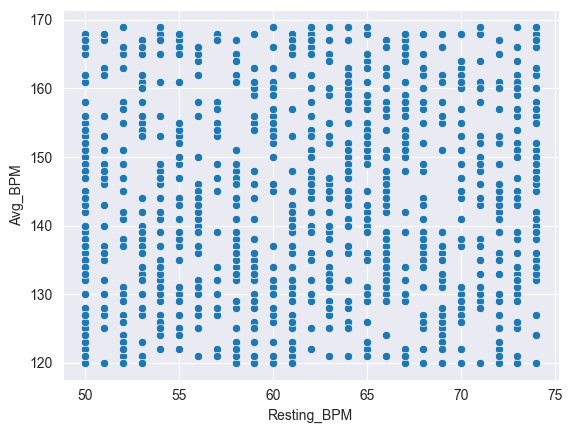

In [24]:
import seaborn as sb
import matplotlib.pyplot as plt

# correlation
plt.figure(figsize=(10, 6))
sb.heatmap(gym_dataset_copy.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# relationship between Resting_BPM and Avg_BPM
sb.scatterplot(data=gym_dataset_copy, x='Resting_BPM', y='Avg_BPM')
plt.show()

### Duplicate Values

In [5]:
#duplicate values elimination

duplicates = gym_dataset_copy[gym_dataset_copy.duplicated()]

if len(duplicates) > 0:
    gym_dataset_copy = gym_dataset_copy.drop_duplicates()
    print(f"{len(duplicates)} duplicates removed.")
else:
    print(f"No duplicates found.")

No duplicates found.


### Handling Missing Values

In [6]:
#checking if there are any missing values

print(gym_dataset_copy.isnull().sum())

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64


**No missing values => No action required**

### Split into Features and Target

In [7]:
X = gym_dataset_copy.drop("Avg_BPM", axis=1)
y = gym_dataset_copy["Avg_BPM"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (973, 12)
y shape: (973,)

Features:
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


### Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (778, 12)
X_test shape: (195, 12)
y_train shape: (778,)
y_test shape: (195,)


### Outliers

In [9]:
train_data = X_train.copy()
train_data['target'] = y_train

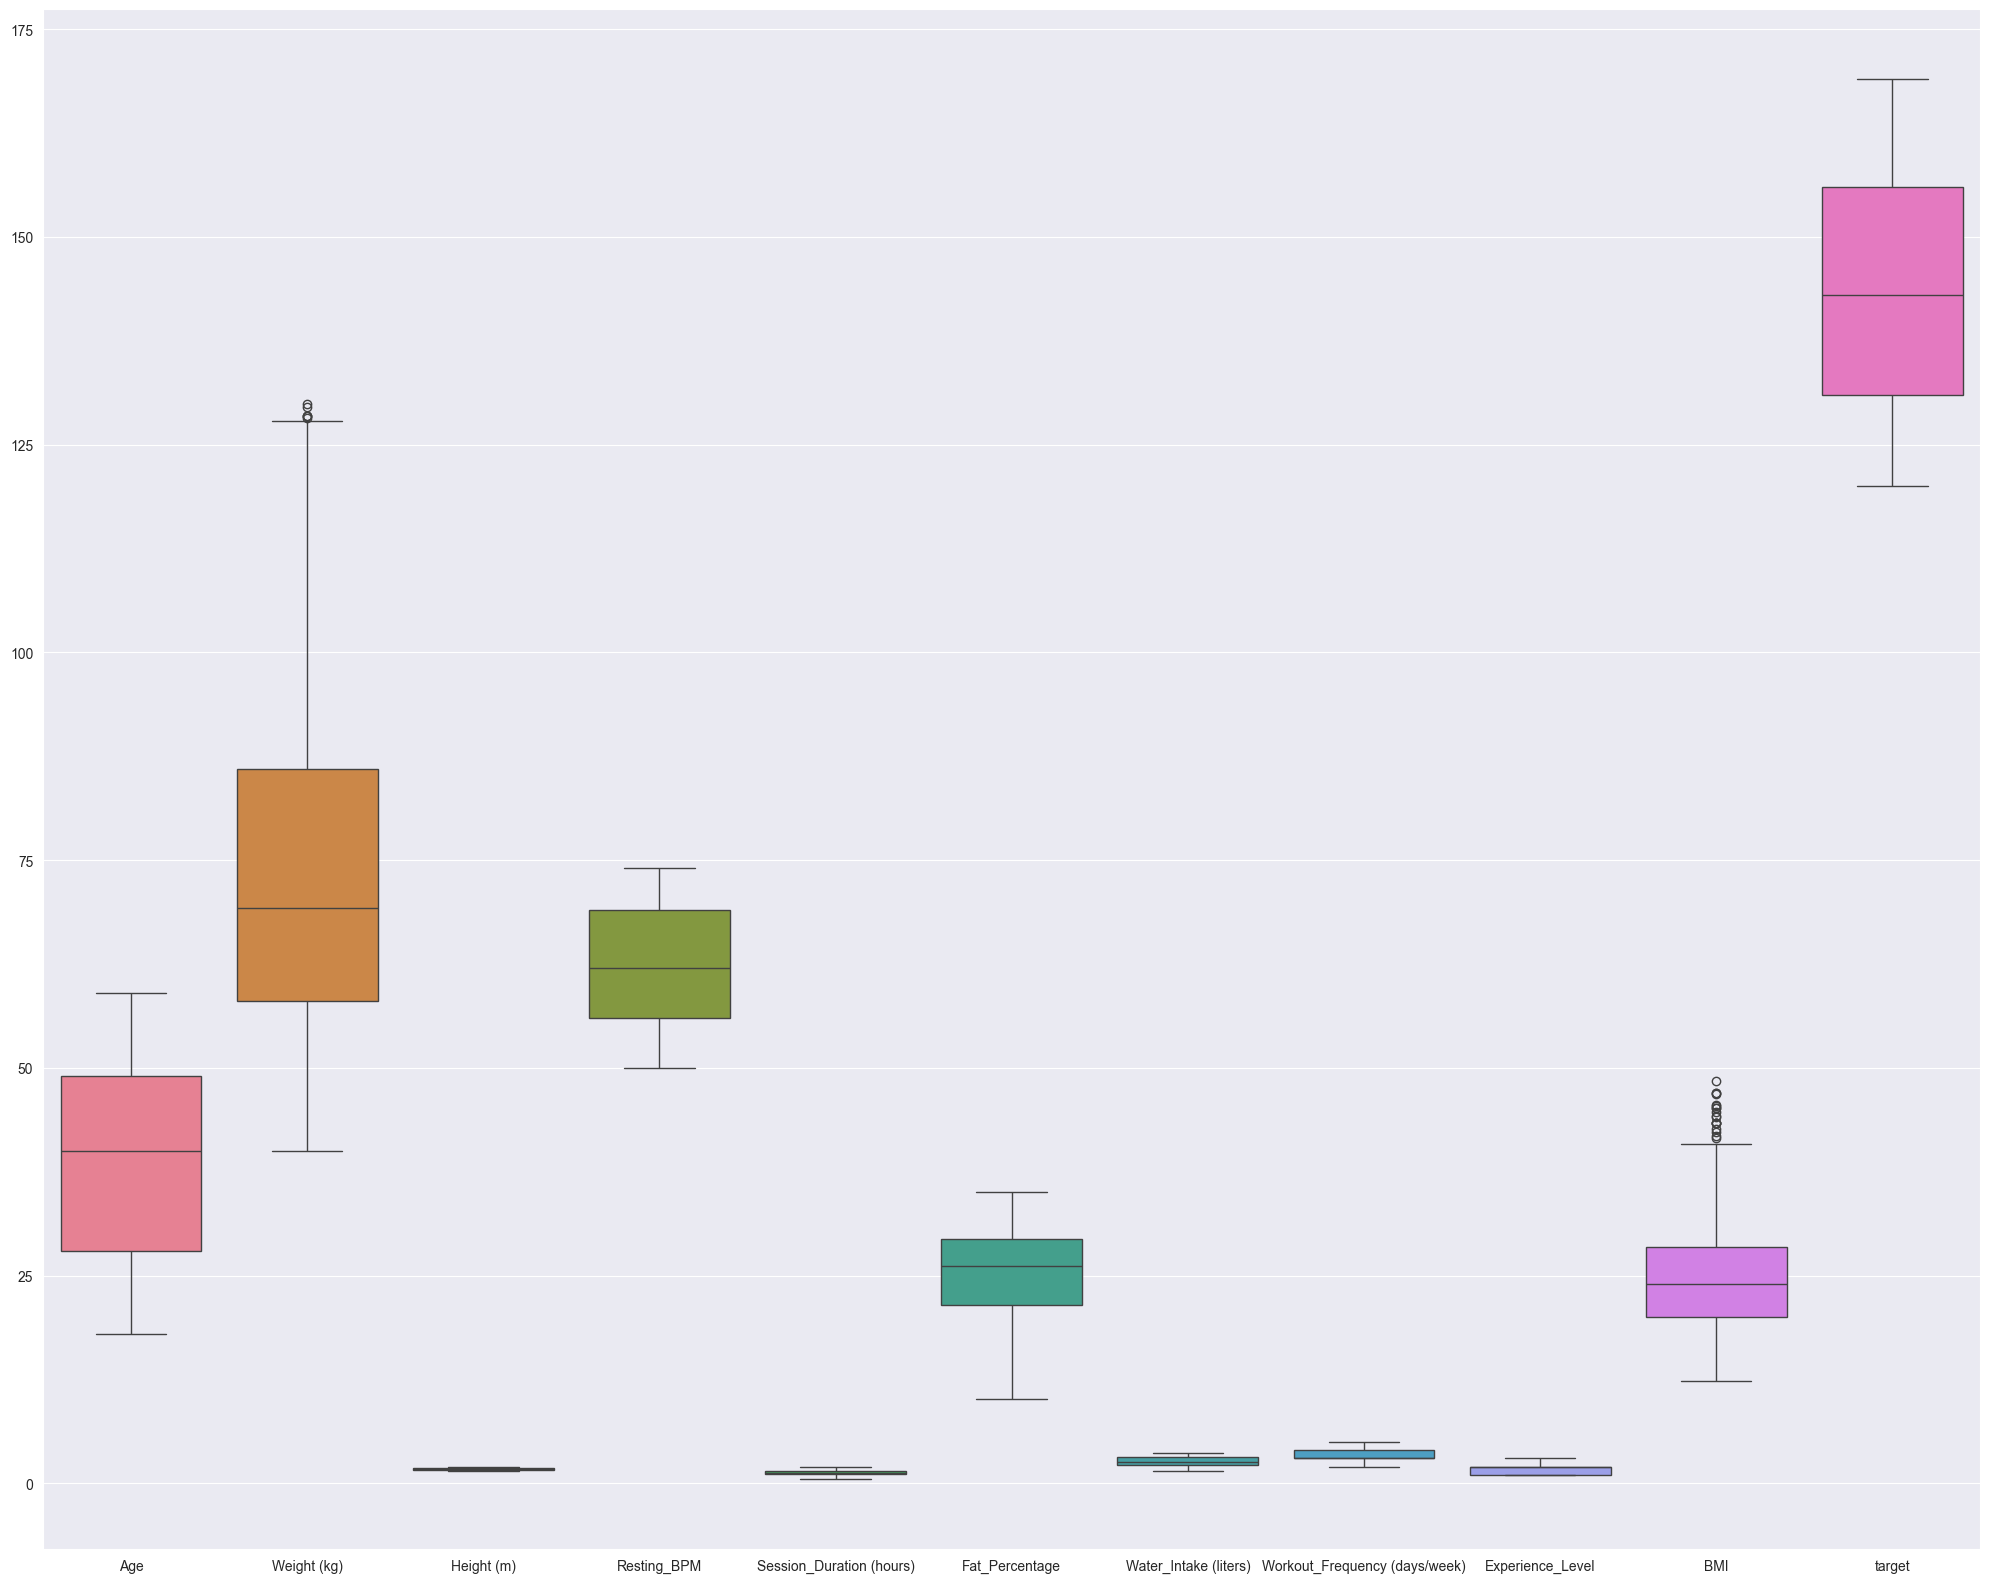

In [10]:
#finding outliers using graphical representation
plt.figure(figsize=(25, 20))
sb.boxplot(train_data)
plt.show()

In [11]:
#finding and removing outliers using IQR method

def remove_outliers_iqr(df):
    df_clean = df.copy()

    numeric_cols = df_clean.select_dtypes(include=['number']).columns

    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        limit_inf = Q1 - 1.5 * IQR
        limit_sup = Q3 + 1.5 * IQR

        before_count = df_clean.shape[0]
        df_clean = df_clean[(df_clean[col] >= limit_inf) & (df_clean[col] <= limit_sup)]
        after_count = df_clean.shape[0]

        removed = before_count - after_count
        if removed > 0:
            print(f"Removed {removed} values out of {col}.")

    return df_clean

In [12]:
train_data_cleaned = remove_outliers_iqr(train_data)

X_train = train_data_cleaned.drop(columns=['target'])
y_train = train_data_cleaned['target']

print("\nFinal Shapes after Outlier Removal:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape} (unchanged)")

Removed 6 values out of Weight (kg).
Removed 17 values out of BMI.

Final Shapes after Outlier Removal:
X_train: (755, 12), y_train: (755,)
X_test: (195, 12) (unchanged)


### Identify Numeric and Categorical Columns

In [13]:
categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Gender', 'Workout_Type']
Numerical columns: ['Age', 'Weight (kg)', 'Height (m)', 'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


### Build the Preprocessing Transformer

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

### Apply Preprocessing

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (755, 16)
X_test_processed shape: (195, 16)


### Convert Processed Data to DataFrame

In [16]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

X_train_processed_df.head()

,num__Age,num__Weight (kg),num__Height (m),num__Resting_BPM,num__Session_Duration (hours),num__Fat_Percentage,num__Water_Intake (liters),num__Workout_Frequency (days/week),num__Experience_Level,num__BMI,cat__Gender_Female,cat__Gender_Male,cat__Workout_Type_Cardio,cat__Workout_Type_HIIT,cat__Workout_Type_Strength,cat__Workout_Type_Yoga
967,-1.541513,-0.875873,-0.971559,0.647737,-0.417525,-0.165664,0.941173,0.730996,0.249405,-0.467711,0.0,1.0,0.0,0.0,0.0,1.0
365,0.025674,-0.588650,-0.586060,0.108403,-1.009454,0.404088,-1.546871,-0.375020,-1.105275,-0.332941,1.0,0.0,0.0,1.0,0.0,0.0
559,1.262926,0.180696,-0.046362,-0.296098,-0.861472,0.214171,-1.215132,-0.375020,-1.105275,0.235509,1.0,0.0,1.0,0.0,0.0,0.0
33,-1.211579,-0.675843,-1.665456,0.782570,-0.654297,1.052973,-0.219915,-1.481036,-1.105275,0.283887,1.0,0.0,1.0,0.0,0.0,0.0
31,-1.541513,-0.342459,-1.588356,-1.644433,-0.683893,0.467394,-0.717523,0.730996,0.249405,0.712385,1.0,0.0,0.0,0.0,0.0,1.0


### Final Check After Preprocessing

In [17]:
print("Train data types after preprocessing:")
print(X_train_processed_df.dtypes.value_counts())

print("\nAny missing values in processed train set?")
print(X_train_processed_df.isnull().sum().sum())

print("\nProcessed train shape:")
print(X_train_processed_df.shape)

print("\nProcessed test shape:")
print(X_test_processed_df.shape)

Train data types after preprocessing:
float64    16
Name: count, dtype: int64

Any missing values in processed train set?
0

Processed train shape:
(755, 16)

Processed test shape:
(195, 16)


### Final Prepared Data

In [18]:
X_prepared = X_train_processed_df.copy()
y_prepared = y_train.copy()

print("Prepared feature set shape:", X_prepared.shape)
print("Prepared target shape:", y_prepared.shape)

Prepared feature set shape: (755, 16)
Prepared target shape: (755,)


In [22]:
X_prepared.to_csv("X_train_prepared.csv", index=True)
y_prepared.to_csv("y_train_prepared.csv", index=True, header=True)

X_test_processed_df.to_csv("X_test_processed.csv", index=True)
y_test.to_csv("y_test.csv", index=True, header=True)

print(f"  X_train_prepared.csv  → {X_prepared.shape}")
print(f"  y_train_prepared.csv  → {y_prepared.shape}")
print(f"  X_test_processed.csv  → {X_test_processed_df.shape}")
print(f"  y_test.csv  → {y_test.shape}")

  X_train_prepared.csv  → (755, 16)
  y_train_prepared.csv  → (755,)
  X_test_processed.csv  → (195, 16)
  y_test.csv  → (195,)
